# 03 — Patient stratification using global gene expression

This notebook explores whether global transcriptomic profiles can stratify TCGA-BRCA samples into biologically meaningful groups.

The analysis uses log-transformed gene expression, highly variable genes, PCA and unsupervised clustering. Clusters are compared with available molecular subtype annotations.

In [23]:
from pathlib import Path

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.metrics import silhouette_score

pd.set_option("display.max_columns", 100)
sns.set_context("notebook")

In [24]:
PROJECT_ROOT = Path("..").resolve()

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "results" / "figures"
TABLES_DIR = PROJECT_ROOT / "results" / "tables"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

expression_path = PROCESSED_DIR / "expression_rsem_samples_by_gene.tsv"
metadata_path = PROCESSED_DIR / "clinical_marker_analysis_table.tsv"

print("Expression exists:", expression_path.exists())
print("Metadata exists:", metadata_path.exists())

Expression exists: True
Metadata exists: True


In [25]:
expression = pd.read_csv(expression_path, sep="\t")
metadata = pd.read_csv(metadata_path, sep="\t")

print("expression:", expression.shape)
print("metadata:", metadata.shape)

display(expression.head())
display(metadata.head())

expression: (1082, 20514)
metadata: (1082, 72)


,SAMPLE_ID_ORIGINAL,SAMPLE_ID_15,PATIENT_ID_12,A1BG,A1CF,A2BP1,A2LD1,A2M,A2M-AS1,A2ML1,A4GALT,A4GNT,AAA1,AAAS,AACS,AACSL,AADAC,AADACL2,AADACL3,AADACL4,AADACP1,AADAT,AAGAB,AAK1,AAMP,AANAT,AARS,AARS2,AARSD1,AASDH,AASDHPPT,AASS,AATBC,AATF,AATK,ABAT,ABCA1,ABCA10,ABCA11P,ABCA12,ABCA13,ABCA17P,ABCA2,ABCA3,ABCA4,ABCA5,ABCA6,ABCA7,ABCA8,ABCA9,...,ZNRF2,ZNRF2P1,ZNRF3,ZNRF4,ZP1,ZP2,ZP3,ZP4,ZPBP,ZPBP2,ZPLD1,ZRANB1,ZRANB2,ZRANB3,ZRSR2,ZSCAN1,ZSCAN10,ZSCAN12,ZSCAN12P1,ZSCAN16,ZSCAN18,ZSCAN2,ZSCAN20,ZSCAN21,ZSCAN22,ZSCAN23,ZSCAN29,ZSCAN4,ZSCAN5A,ZSCAN5B,ZSWIM1,ZSWIM2,ZSWIM3,ZSWIM4,ZSWIM5,ZSWIM6,ZSWIM7,ZUFSP,ZW10,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3,psiTPTE22
0,TCGA-3C-AAAU-01,TCGA-3C-AAAU-01,TCGA-3C-AAAU,197.090,0.0000,0.0000,102.9630,5798.37,32.2187,1.3786,68.2424,8.6165,0.3447,649.337,1087.400,1.3786,0.0000,0.0,0.0000,0.0,0.0000,5.5145,1300.40,517.333,2053.13,0.3447,4409.56,689.897,466.668,277.450,808.914,45.8396,111.6690,1518.91,619.5930,620.731,288.462,16.2334,79.1509,321.2220,0.0000,17.9223,4507.450,5470.770,3.7912,795.093,23.0921,596.9490,58.5920,37.5678,...,414.969,76.1696,741.706,0.0,3.7912,0.0000,411.791,0.0000,1.034,0.3447,53.7668,879.225,2504.080,72.0337,421.862,0.3447,2.7573,141.6550,128.1790,225.062,132.349,582.473,158.8880,253.510,300.887,38.2571,960.220,0.3447,32.3979,1.0340,431.513,0.3447,180.2570,489.416,454.9500,621.764,194.108,89.956,430.824,415.824,931.957,129.5920,1007.780,1658.500,258.4940,1208.370,3507.25,1894.930,1180.460,1.7233
1,TCGA-3C-AALI-01,TCGA-3C-AALI-01,TCGA-3C-AALI,237.384,0.0000,0.0000,70.8646,7571.98,29.9782,4.3502,157.6940,0.5438,0.0000,887.983,836.324,35.3453,1.0875,0.0,0.0000,0.0,0.0000,24.4698,3541.05,848.287,2979.88,2.1751,4570.96,472.501,418.706,184.339,678.630,71.7781,13.5943,7649.27,107.6670,240.348,421.930,17.9445,96.0903,678.6300,1.6313,70.6906,2330.070,2656.880,45.1332,388.798,25.0136,763.4580,20.1196,46.2208,...,841.218,39.6955,373.573,0.0,30.4513,4.3502,439.222,0.5438,0.000,2.1751,3.2626,566.068,627.656,62.5340,349.647,18.4883,0.0000,91.8978,58.2164,174.551,1549.760,236.542,27.7325,698.521,197.390,7.0691,588.363,0.0000,127.7870,4.3502,507.341,0.0000,139.2060,475.802,113.6490,242.523,217.134,105.492,340.402,1161.330,965.198,59.8151,448.613,1343.120,198.4770,603.589,5504.62,1318.650,406.743,926.5910
2,TCGA-3C-AALJ-01,TCGA-3C-AALJ-01,TCGA-3C-AALJ,423.237,0.9066,0.0000,161.2600,8840.40,17.2620,0.0000,573.8890,0.0000,0.0000,723.481,1533.090,2.7199,0.9066,0.0,1.8132,0.0,1.8132,53.4905,1360.83,568.450,2291.93,1.8132,2556.66,439.710,390.752,190.390,779.692,76.1559,20.8522,2097.91,145.0590,375.340,689.882,27.1985,156.0200,0.0000,0.9066,12.6927,3208.520,1514.050,1.8132,559.384,81.5956,383.5000,52.5839,54.3971,...,266.546,38.9846,257.480,0.0,2.7199,0.0000,334.506,0.0000,0.000,0.0000,117.8600,1125.110,1951.210,35.3581,470.535,112.4210,0.0000,99.7280,38.2684,110.607,2225.750,268.359,52.5839,282.865,138.713,46.2375,514.053,0.0000,62.5567,0.0000,352.675,0.0000,81.5956,485.947,180.4170,506.800,164.234,235.721,304.624,305.422,2531.280,35.3581,533.998,768.812,331.8220,532.185,5458.75,942.883,509.519,35.3581
3,TCGA-3C-AALK-01,TCGA-3C-AALK-01,TCGA-3C-AALK,191.018,0.0000,0.0000,62.5072,10960.20,17.8527,1.6549,506.4130,0.0000,0.0000,776.996,858.088,0.0000,2.8962,0.0,0.0000,0.0,1.2412,57.0956,1683.49,727.762,2762.52,0.4137,2122.88,431.936,493.587,196.525,665.288,183.2850,38.8912,1915.18,119.9840,1721.560,749.264,23.5830,137.3230,1430.7000,2.4824,9.1022,1375.260,968.556,73.2313,412.081,78.1961,465.8670,213.4880,70.3351,...,632.602,50.0621,330.161,0.0,1.2412,1.6549,127.017,0.4137,0.000,0.0000,9.1022,780.306,1195.830,61.2329,364.501,6.2060,0.8275,211.8330,33.4506,163.012,1276.380,304.923,36.8225,300.625,122.466,26.4791,409.185,0.4137,57.5093,0.8275,286.305,0.0000,67.0252,626.396,107.5710,340.505,196.136,148.531,314.026,394.506,668.597,55.0269,437.733,863.881,175.4240,607.365,5691.35,781.134,700.869,66.6115
4,TCGA-4H-AAAK-01,TCGA-4H-AAAK-01,TCGA-4H-AAAK,268.881,0.4255,3.8298,154.3700,9585.44,31.5787

,PATIENT_ID_sample,SAMPLE_ID,ONCOTREE_CODE,CANCER_TYPE,CANCER_TYPE_DETAILED,TUMOR_TYPE,GRADE,TISSUE_PROSPECTIVE_COLLECTION_INDICATOR,TISSUE_RETROSPECTIVE_COLLECTION_INDICATOR,TISSUE_SOURCE_SITE_CODE,TUMOR_TISSUE_SITE,ANEUPLOIDY_SCORE,SAMPLE_TYPE,MSI_SCORE_MANTIS,MSI_SENSOR_SCORE,SOMATIC_STATUS,TMB_NONSYNONYMOUS,TISSUE_SOURCE_SITE,TBL_SCORE,SAMPLE_ID_ORIGINAL_x,SAMPLE_ID_15,PATIENT_ID_12,PATIENT_ID_patient,SUBTYPE,CANCER_TYPE_ACRONYM,OTHER_PATIENT_ID,AGE,SEX,AJCC_PATHOLOGIC_TUMOR_STAGE,AJCC_STAGING_EDITION,DAYS_LAST_FOLLOWUP,DAYS_TO_BIRTH,DAYS_TO_INITIAL_PATHOLOGIC_DIAGNOSIS,ETHNICITY,FORM_COMPLETION_DATE,HISTORY_NEOADJUVANT_TRTYN,ICD_10,ICD_O_3_HISTOLOGY,ICD_O_3_SITE,INFORMED_CONSENT_VERIFIED,NEW_TUMOR_EVENT_AFTER_INITIAL_TREATMENT,PATH_M_STAGE,PATH_N_STAGE,PATH_T_STAGE,PERSON_NEOPLASM_CANCER_STATUS,PRIMARY_LYMPH_NODE_PRESENTATION_ASSESSMENT,PRIOR_DX,RACE,RADIATION_THERAPY,WEIGHT,IN_PANCANPATHWAYS_FREEZE,OS_STATUS,OS_MONTHS,DSS_STATUS,DSS_MONTHS,DFS_STATUS,DFS_MONTHS,PFS_STATUS,PFS_MONTHS,GENETIC_ANCESTRY_LABEL,SAMPLE_ID_ORIGINAL_y,SAMPLE_ID_ORIGINAL,ESR1,PGR,ERBB2,MKI67,FOXA1,GATA3,TP53,PIK3CA,BRCA1,BRCA2
0,TCGA-3C-AAAU,TCGA-3C-AAAU-01,ILC,Breast Cancer,Breast Invasive Lobular Carcinoma,Infiltrating Lobular Carcinoma,NaN,No,Yes,3C,Breast,19.0,Primary,0.3319,0.55,Matched,0.800000,Columbia University,205.0,TCGA-3C-AAAU-01,TCGA-3C-AAAU-01,TCGA-3C-AAAU,TCGA-3C-AAAU,BRCA_LumA,BRCA,6E7D5EC6-A469-467C-B748-237353C23416,55,Female,STAGE X,6TH,4047.0,-20211.0,0,Not Hispanic Or Latino,1/13/14,No,C50.9,8520/3,C50.9,Yes,No,MX,NX,TX,With Tumor,Yes,No,White,No,NaN,Yes,0:LIVING,133.050597,0:ALIVE OR DEAD TUMOR FREE,133.050597,1:Recurred/Progressed,59.440444,1:PROGRESSION,59.440444,EUR,TCGA-3C-AAAU-01,TCGA-3C-AAAU-01,3457.9600,2273.2700,7113.41,2582.870,5448.37,14337.50,1385.530,487.003,831.317,178.878
1,TCGA-3C-AALI,TCGA-3C-AALI-01,IDC,Breast Cancer,Breast Invasive Ductal Carcinoma,Infiltrating Ductal Carcinoma,NaN,No,Yes,3C,Breast,22.0,Primary,0.3449,0.74,Matched,15.266667,Columbia University,190.0,TCGA-3C-AALI-01,TCGA-3C-AALI-01,TCGA-3C-AALI,TCGA-3C-AALI,BRCA_Her2,BRCA,55262FCB-1B01-4480-B322-36570430C917,50,Female,STAGE IIB,6TH,4005.0,-18538.0,0,Not Hispanic Or Latino,7/28/14,No,C50.9,8500/3,C50.9,Yes,No,M0,N1A,T2,Tumor Free,Yes,No,Black or African American,Yes,NaN,Yes,0:LIVING,131.669790,0:ALIVE OR DEAD TUMOR FREE,131.669790,0:DiseaseFree,131.669790,0:CENSORED,131.669790,AFR,TCGA-3C-AALI-01,TCGA-3C-AALI-01,68.5155,27.1887,194625.00,2285.480,6049.48,7437.74,414.356,321.914,389.886,153.888
2,TCGA-3C-AALJ,TCGA-3C-AALJ-01,IDC,Breast Cancer,Breast Invasive Ductal Carcinoma,Infiltrating Ductal Carcinoma,NaN,No,Yes,3C,Breast,13.0,Primary,0.3266,0.31,Matched,0.933333,Columbia University,365.0,TCGA-3C-AALJ-01,TCGA-3C-AALJ-01,TCGA-3C-AALJ,TCGA-3C-AALJ,BRCA_LumB,BRCA,427D0648-3F77-4FFC-B52C-89855426D647,62,Female,STAGE IIB,7TH,1474.0,-22848.0,0,Not Hispanic Or Latino,7/28/14,No,C50.9,8500/3,C50.9,Yes,No,M0,N1A,T2,Tumor Free,Yes,No,Black or African American,No,NaN,Yes,0:LIVING,48.459743,0:ALIVE OR DEAD TUMOR FREE,48.459743,0:DiseaseFree,48.459743,0:CENSORED,48.459743,AFR_ADMIX,TCGA-3C-AALJ-01,TCGA-3C-AALJ-01,7482.3200,473.8350,11070.70,949.229,4620.13,10252.90,1289.210,216.682,200.363,151.405
3,TCGA-3C-AALK,TCGA-3C-AALK-01,IDC,Breast Cancer,Breast Invasive Ductal Carcinoma,Infiltrating Ductal Carcinoma,NaN,No,Yes,3C,Breast,4.0,Primary,0.3218,0.03,Matched,1.500000,Columbia University,25.0,TCGA-3C-AALK-01,TCGA-3C-AALK-01,TCGA-3C-AALK,TCGA-3C-AALK,BRCA_LumA,BRCA,C31900A4-5DCD-4022-97AC-638E86E889E4,52,Female,STAGE IA,7TH,1448.0,-19074.0,0,Not Hispanic Or Latino,7/28/14,No,C50.9,8500/3,C50.9,Yes,No,M0,N0 (I+),T1C,Tumor Free,Yes,No,Black or African American,No,NaN,Yes,0:LIVING,47.604958,0:ALIVE OR DEAD TUMOR FREE,47.604958,NaN,NaN,0:CENSORED,47.604958,AFR,TCGA-3C-AALK-01,TCGA-3C-AALK-01,2485.3100,2236.4600,36022.80,1139.430,7352.09,8761.69,1418.290,326.024,148.118,102.193
4,TCGA-4H-AAAK,TCGA-4H-AAAK-01,ILC,Breast Cancer,Breast Invasive Lobular Carcinoma,

In [26]:
id_cols = ["SAMPLE_ID_15", "PATIENT_ID_12"]

for col in id_cols:
    print(col)
    print("  expression:", col in expression.columns)
    print("  metadata:", col in metadata.columns)

print("\nExpression duplicated sample IDs:", expression.duplicated(id_cols).sum())
print("Metadata duplicated sample IDs:", metadata.duplicated(id_cols).sum())

SAMPLE_ID_15
  expression: True
  metadata: True
PATIENT_ID_12
  expression: True
  metadata: True

Expression duplicated sample IDs: 0
Metadata duplicated sample IDs: 0


In [27]:
metadata = metadata.drop_duplicates(subset=id_cols).copy()
print("metadata after dropping duplicated IDs:", metadata.shape)

metadata after dropping duplicated IDs: (1082, 72)


In [28]:
clinical_cols_of_interest = [
    "SUBTYPE",
    "CANCER_TYPE_DETAILED",
    "AJCC_PATHOLOGIC_TUMOR_STAGE",
    "PATH_T_STAGE",
    "PATH_N_STAGE",
    "PATH_M_STAGE",
    "OS_STATUS",
    "OS_MONTHS",
    "DFS_STATUS",
    "DFS_MONTHS",
    "PFS_STATUS",
    "PFS_MONTHS",
    "AGE",
]

clinical_cols_of_interest = [
    col for col in clinical_cols_of_interest
    if col in metadata.columns
]

metadata_small = metadata[id_cols + clinical_cols_of_interest].copy()

print("Clinical columns used:")
print(clinical_cols_of_interest)

display(metadata_small.head())

Clinical columns used:
['SUBTYPE', 'CANCER_TYPE_DETAILED', 'AJCC_PATHOLOGIC_TUMOR_STAGE', 'PATH_T_STAGE', 'PATH_N_STAGE', 'PATH_M_STAGE', 'OS_STATUS', 'OS_MONTHS', 'DFS_STATUS', 'DFS_MONTHS', 'PFS_STATUS', 'PFS_MONTHS', 'AGE']


,SAMPLE_ID_15,PATIENT_ID_12,SUBTYPE,CANCER_TYPE_DETAILED,AJCC_PATHOLOGIC_TUMOR_STAGE,PATH_T_STAGE,PATH_N_STAGE,PATH_M_STAGE,OS_STATUS,OS_MONTHS,DFS_STATUS,DFS_MONTHS,PFS_STATUS,PFS_MONTHS,AGE
0,TCGA-3C-AAAU-01,TCGA-3C-AAAU,BRCA_LumA,Breast Invasive Lobular Carcinoma,STAGE X,TX,NX,MX,0:LIVING,133.050597,1:Recurred/Progressed,59.440444,1:PROGRESSION,59.440444,55
1,TCGA-3C-AALI-01,TCGA-3C-AALI,BRCA_Her2,Breast Invasive Ductal Carcinoma,STAGE IIB,T2,N1A,M0,0:LIVING,131.669790,0:DiseaseFree,131.669790,0:CENSORED,131.669790,50
2,TCGA-3C-AALJ-01,TCGA-3C-AALJ,BRCA_LumB,Breast Invasive Ductal Carcinoma,STAGE IIB,T2,N1A,M0,0:LIVING,48.459743,0:DiseaseFree,48.459743,0:CENSORED,48.459743,62
3,TCGA-3C-AALK-01,TCGA-3C-AALK,BRCA_LumA,Breast Invasive Ductal Carcinoma,STAGE IA,T1C,N0 (I+),M0,0:LIVING,47.604958,NaN,NaN,0:CENSORED,47.604958,52
4,TCGA-4H-AAAK-01,TCGA-4H-AAAK,BRCA_LumA,Breast Invasive Lobular Carcinoma,STAGE IIIA,T2,N2A,M0,0:LIVING,11.440971,0:DiseaseFree,11.440971,0:CENSORED,11.440971,50


In [29]:
df = expression.merge(
    metadata_small,
    on=id_cols,
    how="inner"
)

print("Merged table:", df.shape)
display(df.head())

Merged table: (1082, 20527)


,SAMPLE_ID_ORIGINAL,SAMPLE_ID_15,PATIENT_ID_12,A1BG,A1CF,A2BP1,A2LD1,A2M,A2M-AS1,A2ML1,A4GALT,A4GNT,AAA1,AAAS,AACS,AACSL,AADAC,AADACL2,AADACL3,AADACL4,AADACP1,AADAT,AAGAB,AAK1,AAMP,AANAT,AARS,AARS2,AARSD1,AASDH,AASDHPPT,AASS,AATBC,AATF,AATK,ABAT,ABCA1,ABCA10,ABCA11P,ABCA12,ABCA13,ABCA17P,ABCA2,ABCA3,ABCA4,ABCA5,ABCA6,ABCA7,ABCA8,ABCA9,...,ZRANB3,ZRSR2,ZSCAN1,ZSCAN10,ZSCAN12,ZSCAN12P1,ZSCAN16,ZSCAN18,ZSCAN2,ZSCAN20,ZSCAN21,ZSCAN22,ZSCAN23,ZSCAN29,ZSCAN4,ZSCAN5A,ZSCAN5B,ZSWIM1,ZSWIM2,ZSWIM3,ZSWIM4,ZSWIM5,ZSWIM6,ZSWIM7,ZUFSP,ZW10,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3,psiTPTE22,SUBTYPE,CANCER_TYPE_DETAILED,AJCC_PATHOLOGIC_TUMOR_STAGE,PATH_T_STAGE,PATH_N_STAGE,PATH_M_STAGE,OS_STATUS,OS_MONTHS,DFS_STATUS,DFS_MONTHS,PFS_STATUS,PFS_MONTHS,AGE
0,TCGA-3C-AAAU-01,TCGA-3C-AAAU-01,TCGA-3C-AAAU,197.090,0.0000,0.0000,102.9630,5798.37,32.2187,1.3786,68.2424,8.6165,0.3447,649.337,1087.400,1.3786,0.0000,0.0,0.0000,0.0,0.0000,5.5145,1300.40,517.333,2053.13,0.3447,4409.56,689.897,466.668,277.450,808.914,45.8396,111.6690,1518.91,619.5930,620.731,288.462,16.2334,79.1509,321.2220,0.0000,17.9223,4507.450,5470.770,3.7912,795.093,23.0921,596.9490,58.5920,37.5678,...,72.0337,421.862,0.3447,2.7573,141.6550,128.1790,225.062,132.349,582.473,158.8880,253.510,300.887,38.2571,960.220,0.3447,32.3979,1.0340,431.513,0.3447,180.2570,489.416,454.9500,621.764,194.108,89.956,430.824,415.824,931.957,129.5920,1007.780,1658.500,258.4940,1208.370,3507.25,1894.930,1180.460,1.7233,BRCA_LumA,Breast Invasive Lobular Carcinoma,STAGE X,TX,NX,MX,0:LIVING,133.050597,1:Recurred/Progressed,59.440444,1:PROGRESSION,59.440444,55
1,TCGA-3C-AALI-01,TCGA-3C-AALI-01,TCGA-3C-AALI,237.384,0.0000,0.0000,70.8646,7571.98,29.9782,4.3502,157.6940,0.5438,0.0000,887.983,836.324,35.3453,1.0875,0.0,0.0000,0.0,0.0000,24.4698,3541.05,848.287,2979.88,2.1751,4570.96,472.501,418.706,184.339,678.630,71.7781,13.5943,7649.27,107.6670,240.348,421.930,17.9445,96.0903,678.6300,1.6313,70.6906,2330.070,2656.880,45.1332,388.798,25.0136,763.4580,20.1196,46.2208,...,62.5340,349.647,18.4883,0.0000,91.8978,58.2164,174.551,1549.760,236.542,27.7325,698.521,197.390,7.0691,588.363,0.0000,127.7870,4.3502,507.341,0.0000,139.2060,475.802,113.6490,242.523,217.134,105.492,340.402,1161.330,965.198,59.8151,448.613,1343.120,198.4770,603.589,5504.62,1318.650,406.743,926.5910,BRCA_Her2,Breast Invasive Ductal Carcinoma,STAGE IIB,T2,N1A,M0,0:LIVING,131.669790,0:DiseaseFree,131.669790,0:CENSORED,131.669790,50
2,TCGA-3C-AALJ-01,TCGA-3C-AALJ-01,TCGA-3C-AALJ,423.237,0.9066,0.0000,161.2600,8840.40,17.2620,0.0000,573.8890,0.0000,0.0000,723.481,1533.090,2.7199,0.9066,0.0,1.8132,0.0,1.8132,53.4905,1360.83,568.450,2291.93,1.8132,2556.66,439.710,390.752,190.390,779.692,76.1559,20.8522,2097.91,145.0590,375.340,689.882,27.1985,156.0200,0.0000,0.9066,12.6927,3208.520,1514.050,1.8132,559.384,81.5956,383.5000,52.5839,54.3971,...,35.3581,470.535,112.4210,0.0000,99.7280,38.2684,110.607,2225.750,268.359,52.5839,282.865,138.713,46.2375,514.053,0.0000,62.5567,0.0000,352.675,0.0000,81.5956,485.947,180.4170,506.800,164.234,235.721,304.624,305.422,2531.280,35.3581,533.998,768.812,331.8220,532.185,5458.75,942.883,509.519,35.3581,BRCA_LumB,Breast Invasive Ductal Carcinoma,STAGE IIB,T2,N1A,M0,0:LIVING,48.459743,0:DiseaseFree,48.459743,0:CENSORED,48.459743,62
3,TCGA-3C-AALK-01,TCGA-3C-AALK-01,TCGA-3C-AALK,191.018,0.0000,0.0000,62.5072,10960.20,17.8527,1.6549,506.4130,0.0000,0.0000,776.996,858.088,0.0000,2.8962,0.0,0.0000,0.0,1.2412,57.0956,1683.49,727.762,2762.52,0.4137,2122.88,431.936,493.587,196.525,665.288,183.2850,38.8912,1915.18,119.9840,1721.560,749.264,23.5830,137.3230,1430.7000,2.4824,9.1022,1375.260,968.556,73.2313,412.081,78.1961,465.8670,213.4880,70.3351,...,61.2329,364.501,6.2060,0.8275,211.8330,33.4506,163.012,1276.380,304.923,36.8225,300.625,122.466,26.4791,409.185,0.4137,57.5093,0.8275,286.305,0.0000,67.0252,626.396,107.5710,340.505,196.136,148.531,314.026,394.506,668.597,55.0269,437.733,863.881,175.4240,607.365,5691.35,781

In [30]:
non_gene_cols = set(id_cols + clinical_cols_of_interest)

# También excluimos columnas auxiliares si existen
extra_non_gene_cols = [
    "SAMPLE_ID",
    "SAMPLE_ID_ORIGINAL",
]

non_gene_cols.update([col for col in extra_non_gene_cols if col in df.columns])

gene_cols = [
    col for col in expression.columns
    if col not in non_gene_cols
    and col not in extra_non_gene_cols
]

print("Number of genes:", len(gene_cols))
print("First genes:", gene_cols[:10])

Number of genes: 20511
First genes: ['A1BG', 'A1CF', 'A2BP1', 'A2LD1', 'A2M', 'A2M-AS1', 'A2ML1', 'A4GALT', 'A4GNT', 'AAA1']


In [31]:
X_raw = df[gene_cols].copy()

# Convert to numeric just in case
X_raw = X_raw.apply(pd.to_numeric, errors="coerce")

# Remove genes with too many missing values
missing_fraction = X_raw.isna().mean(axis=0)
genes_keep_missing = missing_fraction[missing_fraction < 0.05].index.tolist()

X_raw = X_raw[genes_keep_missing]

# Impute remaining missing values with gene median
X_raw = X_raw.fillna(X_raw.median(axis=0))

# Log-transform
X_log = np.log2(X_raw + 1)

print("X_raw:", X_raw.shape)
print("X_log:", X_log.shape)

X_raw: (1082, 20511)
X_log: (1082, 20511)


In [32]:
n_top_genes = 2000

gene_variances = X_log.var(axis=0).sort_values(ascending=False)
top_variable_genes = gene_variances.head(n_top_genes).index.tolist()

X_hvg = X_log[top_variable_genes].copy()

print("Highly variable expression matrix:", X_hvg.shape)

gene_variances.head(20).to_csv(TABLES_DIR / "top_variable_genes.csv")
display(gene_variances.head(20).reset_index().rename(columns={"index": "gene", 0: "variance"}))

Highly variable expression matrix: (1082, 2000)


,gene,variance
0,CLEC3A,26.902211
1,CPB1,26.596435
2,SCGB2A2,25.277209
3,SCGB1D2,20.039653
4,TFF1,19.758742
5,GSTM1,18.735859
6,PIP,18.160859
7,S100A7,17.708833
8,MUCL1,17.599928
9,CYP2B7P1,17.357565


In [33]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_hvg)

print("Scaled matrix:", X_scaled.shape)

Scaled matrix: (1082, 2000)


In [34]:
pca = PCA(n_components=20, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca_cols = [f"PC{i}" for i in range(1, X_pca.shape[1] + 1)]

pca_df = pd.DataFrame(
    X_pca,
    columns=pca_cols,
    index=df.index
)

pca_df[id_cols] = df[id_cols].values

for col in clinical_cols_of_interest:
    pca_df[col] = df[col].values

explained_variance = pd.DataFrame({
    "PC": pca_cols,
    "explained_variance_ratio": pca.explained_variance_ratio_,
    "cumulative_explained_variance": np.cumsum(pca.explained_variance_ratio_)
})

display(explained_variance.head(10))

explained_variance.to_csv(TABLES_DIR / "pca_explained_variance.csv", index=False)
pca_df.to_csv(TABLES_DIR / "pca_coordinates.csv", index=False)

,PC,explained_variance_ratio,cumulative_explained_variance
0,PC1,0.143882,0.143882
1,PC2,0.087239,0.231121
2,PC3,0.040954,0.272075
3,PC4,0.033250,0.305325
4,PC5,0.027051,0.332376
5,PC6,0.022649,0.355025
6,PC7,0.019895,0.374921
7,PC8,0.017725,0.392646
8,PC9,0.014998,0.407644
9,PC10,0.013030,0.420673


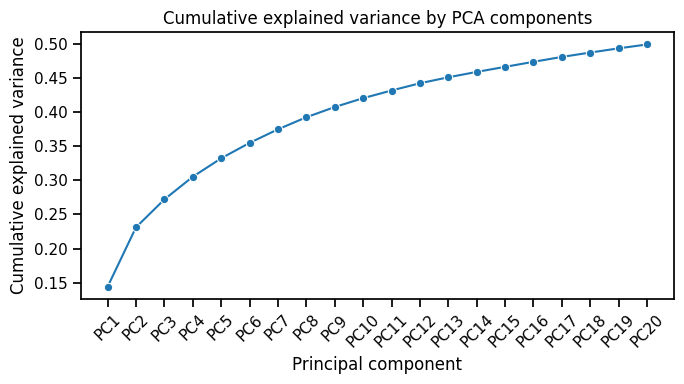

In [35]:
plt.figure(figsize=(7, 4))
sns.lineplot(
    data=explained_variance.head(20),
    x="PC",
    y="cumulative_explained_variance",
    marker="o"
)
plt.title("Cumulative explained variance by PCA components")
plt.xlabel("Principal component")
plt.ylabel("Cumulative explained variance")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "pca_cumulative_explained_variance.png", dpi=300)
plt.show()

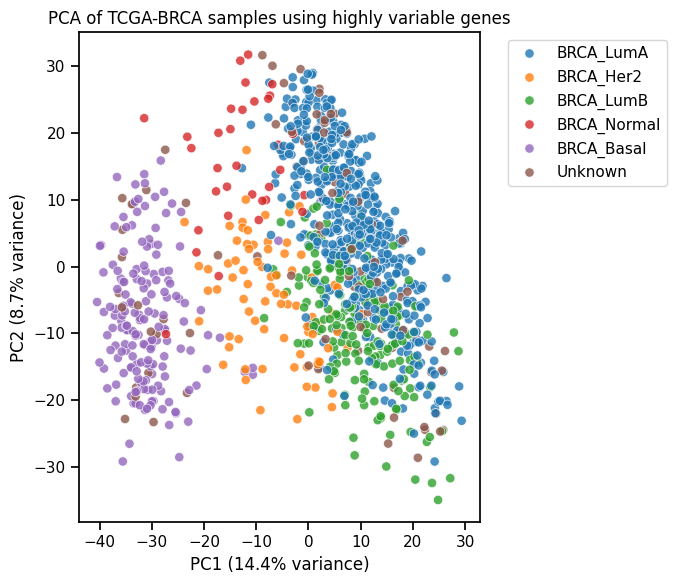

In [36]:
if "SUBTYPE" in pca_df.columns:
    plot_df = pca_df.copy()
    plot_df["SUBTYPE"] = plot_df["SUBTYPE"].fillna("Unknown")
    
    plt.figure(figsize=(7, 6))
    sns.scatterplot(
        data=plot_df,
        x="PC1",
        y="PC2",
        hue="SUBTYPE",
        alpha=0.8,
        s=45
    )
    plt.title("PCA of TCGA-BRCA samples using highly variable genes")
    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "pca_pc1_pc2_by_subtype.png", dpi=300)
    plt.show()
else:
    print("SUBTYPE column not available.")

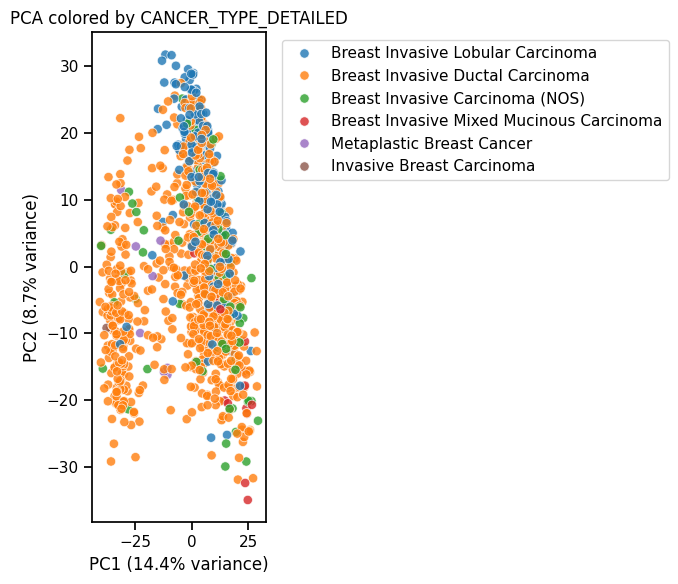

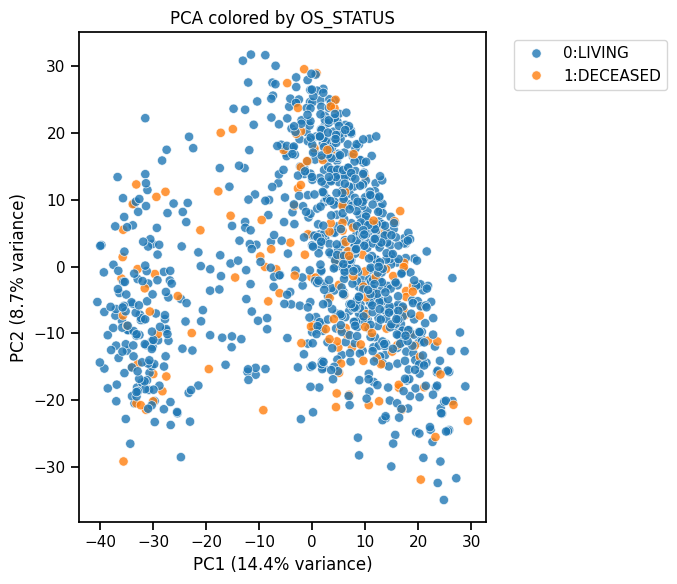

In [37]:
for col in ["CANCER_TYPE_DETAILED", "AJCC_PATHOLOGIC_TUMOR_STAGE", "OS_STATUS"]:
    if col in pca_df.columns:
        plot_df = pca_df.copy()
        plot_df[col] = plot_df[col].fillna("Unknown")
        
        # Avoid plotting variables with too many categories
        if plot_df[col].nunique() <= 12:
            plt.figure(figsize=(7, 6))
            sns.scatterplot(
                data=plot_df,
                x="PC1",
                y="PC2",
                hue=col,
                alpha=0.8,
                s=45
            )
            plt.title(f"PCA colored by {col}")
            plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
            plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
            plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
            plt.tight_layout()
            
            safe_col = col.lower().replace(" ", "_").replace("/", "_")
            plt.savefig(FIGURES_DIR / f"pca_pc1_pc2_by_{safe_col}.png", dpi=300)
            plt.show()

In [38]:
cluster_results = []

for k in range(2, 9):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=50)
    labels = kmeans.fit_predict(X_pca[:, :10])
    
    sil = silhouette_score(X_pca[:, :10], labels)
    
    result = {
        "k": k,
        "silhouette_score": sil,
    }
    
    if "SUBTYPE" in df.columns:
        valid = df["SUBTYPE"].notna()
        if valid.sum() > 0:
            result["adjusted_rand_index_vs_subtype"] = adjusted_rand_score(
                df.loc[valid, "SUBTYPE"],
                labels[valid]
            )
            result["normalized_mutual_info_vs_subtype"] = normalized_mutual_info_score(
                df.loc[valid, "SUBTYPE"],
                labels[valid]
            )
    
    cluster_results.append(result)

cluster_results_df = pd.DataFrame(cluster_results)

display(cluster_results_df)

cluster_results_df.to_csv(TABLES_DIR / "kmeans_cluster_evaluation.csv", index=False)

,k,silhouette_score,adjusted_rand_index_vs_subtype,normalized_mutual_info_vs_subtype
0,2,0.330443,0.376691,0.482479
1,3,0.226395,0.331941,0.457700
2,4,0.221858,0.384470,0.508940
3,5,0.191029,0.337328,0.483501
4,6,0.190047,0.329281,0.480152
5,7,0.162641,0.286215,0.456703
6,8,0.152608,0.269137,0.448253


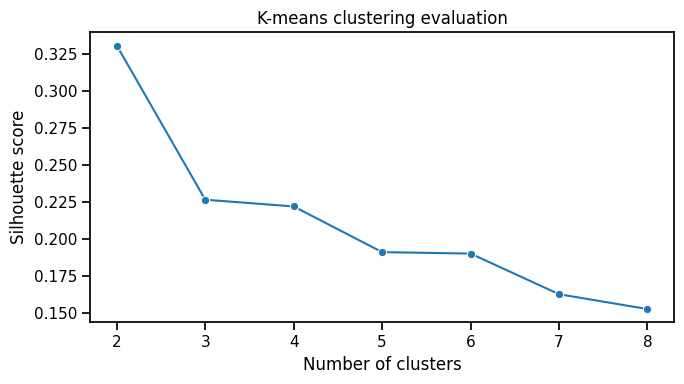

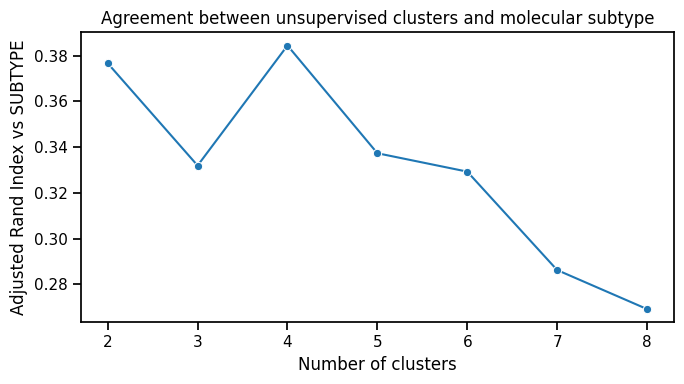

In [39]:
plt.figure(figsize=(7, 4))
sns.lineplot(
    data=cluster_results_df,
    x="k",
    y="silhouette_score",
    marker="o"
)
plt.title("K-means clustering evaluation")
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette score")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "kmeans_silhouette_scores.png", dpi=300)
plt.show()

if "adjusted_rand_index_vs_subtype" in cluster_results_df.columns:
    plt.figure(figsize=(7, 4))
    sns.lineplot(
        data=cluster_results_df,
        x="k",
        y="adjusted_rand_index_vs_subtype",
        marker="o"
    )
    plt.title("Agreement between unsupervised clusters and molecular subtype")
    plt.xlabel("Number of clusters")
    plt.ylabel("Adjusted Rand Index vs SUBTYPE")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "kmeans_ari_vs_subtype.png", dpi=300)
    plt.show()

In [40]:
final_k = 4

kmeans = KMeans(n_clusters=final_k, random_state=42, n_init=50)
cluster_labels = kmeans.fit_predict(X_pca[:, :10])

pca_df["KMEANS_CLUSTER"] = cluster_labels.astype(str)

display(pca_df[["SAMPLE_ID_15", "PATIENT_ID_12", "SUBTYPE", "KMEANS_CLUSTER"]].head())

,SAMPLE_ID_15,PATIENT_ID_12,SUBTYPE,KMEANS_CLUSTER
0,TCGA-3C-AAAU-01,TCGA-3C-AAAU,BRCA_LumA,3
1,TCGA-3C-AALI-01,TCGA-3C-AALI,BRCA_Her2,0
2,TCGA-3C-AALJ-01,TCGA-3C-AALJ,BRCA_LumB,0
3,TCGA-3C-AALK-01,TCGA-3C-AALK,BRCA_LumA,2
4,TCGA-4H-AAAK-01,TCGA-4H-AAAK,BRCA_LumA,2


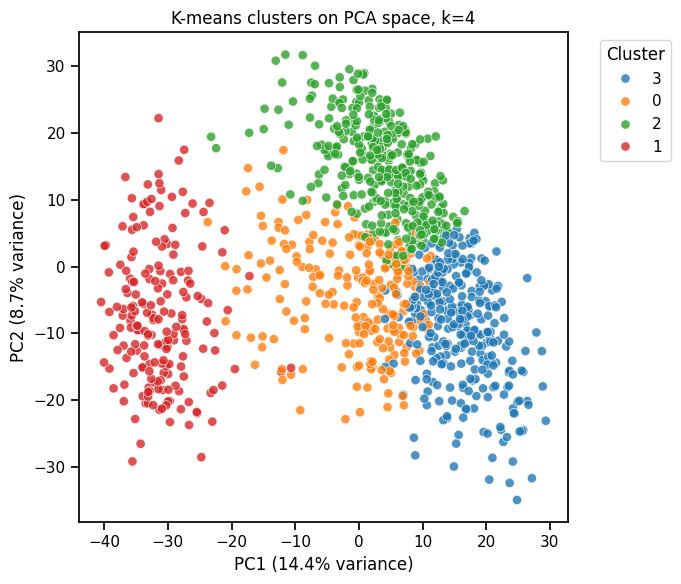

In [41]:
plt.figure(figsize=(7, 6))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="KMEANS_CLUSTER",
    alpha=0.8,
    s=45,
    palette="tab10"
)
plt.title(f"K-means clusters on PCA space, k={final_k}")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig(FIGURES_DIR / f"pca_pc1_pc2_kmeans_k{final_k}.png", dpi=300)
plt.show()

In [42]:
if "SUBTYPE" in pca_df.columns:
    cluster_subtype_table = pd.crosstab(
        pca_df["KMEANS_CLUSTER"],
        pca_df["SUBTYPE"].fillna("Unknown")
    )
    
    display(cluster_subtype_table)
    
    cluster_subtype_table.to_csv(TABLES_DIR / f"kmeans_k{final_k}_cluster_vs_subtype_counts.csv")
    
    cluster_subtype_prop = cluster_subtype_table.div(
        cluster_subtype_table.sum(axis=1),
        axis=0
    )
    
    display(cluster_subtype_prop)
    
    cluster_subtype_prop.to_csv(TABLES_DIR / f"kmeans_k{final_k}_cluster_vs_subtype_proportions.csv")

SUBTYPE,BRCA_Basal,BRCA_Her2,BRCA_LumA,BRCA_LumB,BRCA_Normal,Unknown
KMEANS_CLUSTER,,,,,,
0,4,78,47,81,6,11
1,167,0,0,0,5,20
2,0,0,286,11,25,38
3,0,0,166,105,0,32


SUBTYPE,BRCA_Basal,BRCA_Her2,BRCA_LumA,BRCA_LumB,BRCA_Normal,Unknown
KMEANS_CLUSTER,,,,,,
0,0.017621,0.343612,0.207048,0.356828,0.026432,0.048458
1,0.869792,0.000000,0.000000,0.000000,0.026042,0.104167
2,0.000000,0.000000,0.794444,0.030556,0.069444,0.105556
3,0.000000,0.000000,0.547855,0.346535,0.000000,0.105611


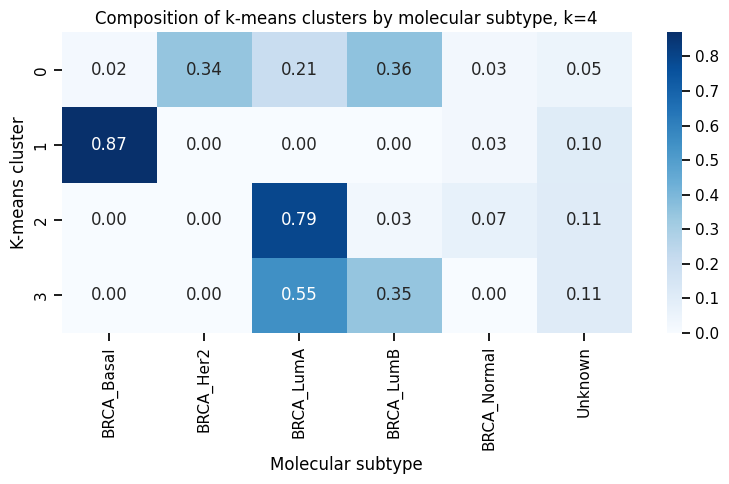

In [43]:
if "SUBTYPE" in pca_df.columns:
    plt.figure(figsize=(8, 5))
    sns.heatmap(
        cluster_subtype_prop,
        annot=True,
        fmt=".2f",
        cmap="Blues"
    )
    plt.title(f"Composition of k-means clusters by molecular subtype, k={final_k}")
    plt.xlabel("Molecular subtype")
    plt.ylabel("K-means cluster")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"kmeans_k{final_k}_cluster_vs_subtype_heatmap.png", dpi=300)
    plt.show()

In [45]:
stratification_results = pca_df.copy()

stratification_results.to_csv(
    TABLES_DIR / f"patient_stratification_pca_kmeans_k{final_k}.csv",
    index=False
)

print("Saved stratification results.")

Saved stratification results.


In [46]:
marker_genes = [
    "ESR1",
    "PGR",
    "ERBB2",
    "MKI67",
    "FOXA1",
    "GATA3",
    "TP53",
    "PIK3CA",
    "BRCA1",
    "BRCA2",
]

marker_genes = [gene for gene in marker_genes if gene in metadata.columns]

cluster_marker_df = pca_df[
    ["SAMPLE_ID_15", "PATIENT_ID_12", "SUBTYPE", "KMEANS_CLUSTER"]
].merge(
    metadata[["SAMPLE_ID_15", "PATIENT_ID_12"] + marker_genes],
    on=["SAMPLE_ID_15", "PATIENT_ID_12"],
    how="left"
)

for gene in marker_genes:
    cluster_marker_df[f"log2_{gene}"] = np.log2(cluster_marker_df[gene] + 1)

display(cluster_marker_df.head())

,SAMPLE_ID_15,PATIENT_ID_12,SUBTYPE,KMEANS_CLUSTER,ESR1,PGR,ERBB2,MKI67,FOXA1,GATA3,TP53,PIK3CA,BRCA1,BRCA2,log2_ESR1,log2_PGR,log2_ERBB2,log2_MKI67,log2_FOXA1,log2_GATA3,log2_TP53,log2_PIK3CA,log2_BRCA1,log2_BRCA2
0,TCGA-3C-AAAU-01,TCGA-3C-AAAU,BRCA_LumA,3,3457.9600,2273.2700,7113.41,2582.870,5448.37,14337.50,1385.530,487.003,831.317,178.878,11.756123,11.151188,12.796528,11.335318,12.411874,13.807606,10.437263,8.930746,9.700989,7.490875
1,TCGA-3C-AALI-01,TCGA-3C-AALI,BRCA_Her2,0,68.5155,27.1887,194625.00,2285.480,6049.48,7437.74,414.356,321.914,389.886,153.888,6.119263,4.817045,17.570345,11.158913,12.562834,12.860843,8.698205,8.335006,8.610604,7.275082
2,TCGA-3C-AALJ-01,TCGA-3C-AALJ,BRCA_LumB,0,7482.3200,473.8350,11070.70,949.229,4620.13,10252.90,1289.210,216.682,200.363,151.405,12.869463,8.891282,13.434589,9.892131,12.174030,13.323885,10.333390,7.766078,7.653655,7.251766
3,TCGA-3C-AALK-01,TCGA-3C-AALK,BRCA_LumA,2,2485.3100,2236.4600,36022.80,1139.430,7352.09,8761.69,1418.290,326.024,148.118,102.193,11.279790,11.127646,15.136663,10.155362,12.844135,13.097158,10.470954,8.353253,7.220311,6.689201
4,TCGA-4H-AAAK-01,TCGA-4H-AAAK,BRCA_LumA,2,5518.3000,4425.1900,12236.60,1206.380,6799.57,14068.50,1484.260,410.213,375.745,128.936,12.430270,12.111850,13.579033,10.237664,12.731440,13.780283,10.536500,8.683742,8.557445,7.021657


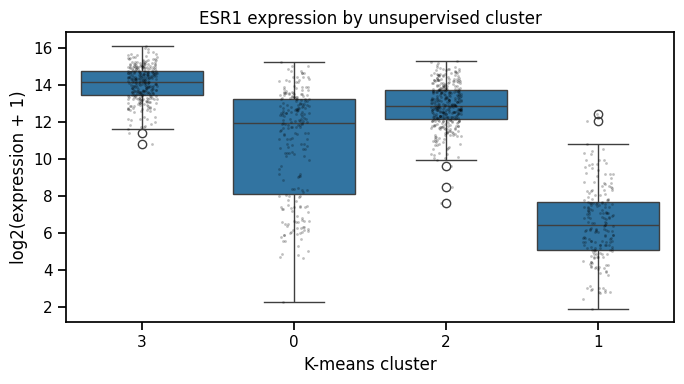

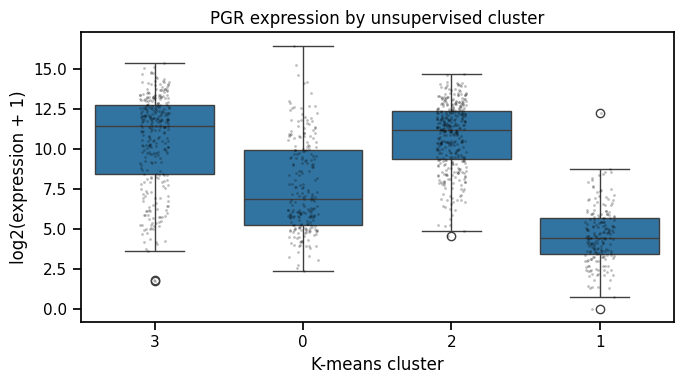

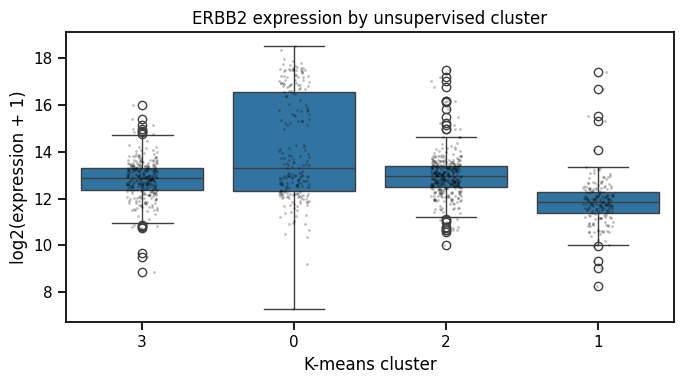

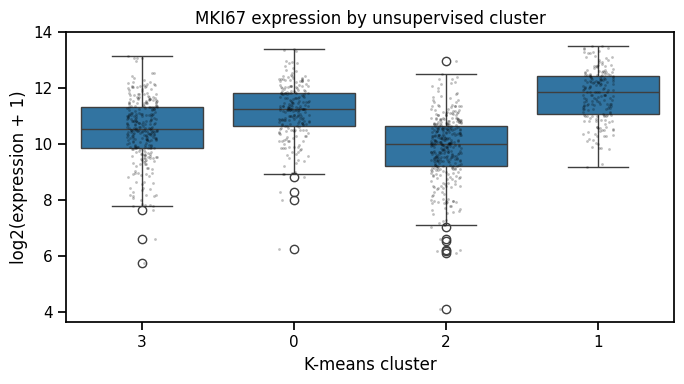

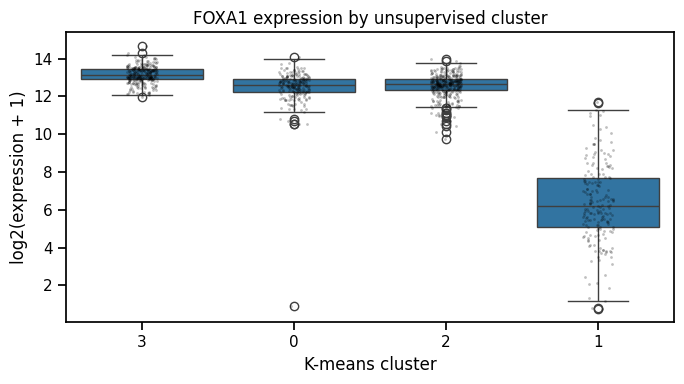

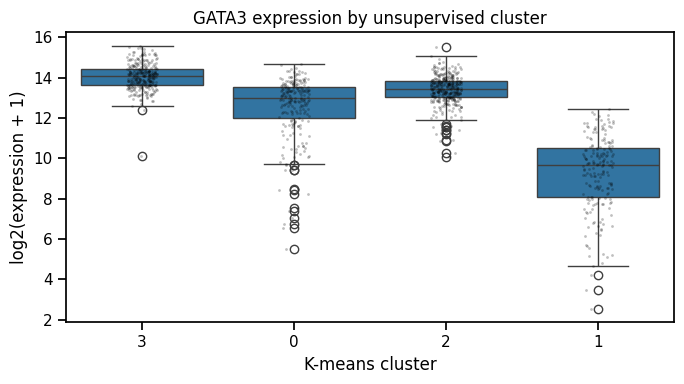

In [47]:
for gene in ["ESR1", "PGR", "ERBB2", "MKI67", "FOXA1", "GATA3"]:
    if f"log2_{gene}" in cluster_marker_df.columns:
        plt.figure(figsize=(7, 4))
        sns.boxplot(
            data=cluster_marker_df,
            x="KMEANS_CLUSTER",
            y=f"log2_{gene}"
        )
        sns.stripplot(
            data=cluster_marker_df,
            x="KMEANS_CLUSTER",
            y=f"log2_{gene}",
            color="black",
            alpha=0.25,
            size=2
        )
        plt.title(f"{gene} expression by unsupervised cluster")
        plt.xlabel("K-means cluster")
        plt.ylabel("log2(expression + 1)")
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / f"{gene}_by_kmeans_cluster_log2.png", dpi=300)
        plt.show()

In [48]:
cluster_marker_summary = (
    cluster_marker_df
    .groupby("KMEANS_CLUSTER")[[f"log2_{gene}" for gene in marker_genes]]
    .median()
)

display(cluster_marker_summary)

cluster_marker_summary.to_csv(
    TABLES_DIR / f"kmeans_k{final_k}_cluster_marker_median_expression.csv"
)

,log2_ESR1,log2_PGR,log2_ERBB2,log2_MKI67,log2_FOXA1,log2_GATA3,log2_TP53,log2_PIK3CA,log2_BRCA1,log2_BRCA2
KMEANS_CLUSTER,,,,,,,,,,
0,11.957592,6.892731,13.287066,11.255088,12.607763,12.972834,10.634067,9.036152,8.542258,7.665776
1,6.426178,4.472393,11.865263,11.874762,6.214910,9.660331,10.846724,9.215315,8.491135,7.817443
2,12.849096,11.191362,12.955606,10.018012,12.646362,13.451900,10.625132,9.077018,8.046367,6.798581
3,14.181828,11.420339,12.889318,10.558344,13.161792,14.066350,10.632395,8.967739,8.817674,7.176791


## Interpretation

The PCA shows that global transcriptomic variation captures known biological structure in TCGA-BRCA. Basal-like tumours form the most clearly separated group, while Luminal A, Luminal B and HER2-enriched samples show partial overlap.

K-means clustering does not perfectly reproduce molecular subtype labels, which is expected because unsupervised clustering optimizes geometric separation rather than agreement with predefined clinical or molecular annotations. However, cluster composition shows that Basal-like tumours are strongly enriched in one cluster, while luminal samples are distributed across multiple clusters, suggesting additional heterogeneity within hormone-receptor-positive disease.

These results support the use of global expression profiles for exploratory patient stratification, while highlighting that breast cancer subtype structure is not fully captured by simple hard clustering.